# Logistic Regression

## Types of Logistic Regression

## Multinomial Logistic Regression

Now, your target can have more than two classes. Then  you use Multinomial Logistic Regression, one example could be “disease A” vs “disease B” vs “disease C”.

#### What changes from Binomial Logistic Regression?


Instead of using **Sigmoid funtion** we will use **Softmax function**!

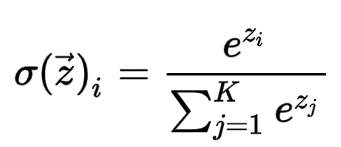

Needs more information about this? https://deepai.org/machine-learning-glossary-and-terms/softmax-layer


For this problem we will use a data set based in hand written numbers. 

The hand written numbers are 32x32 bitmaps, they are divided into nonoverlapping blocks of 4x4 and the number of on pixels are counted in each block. 

This generates an input matrix of 8x8 where each element is an integer in the range 0..16. This reduces dimensionality and gives invariance to small distortions.

What that means?

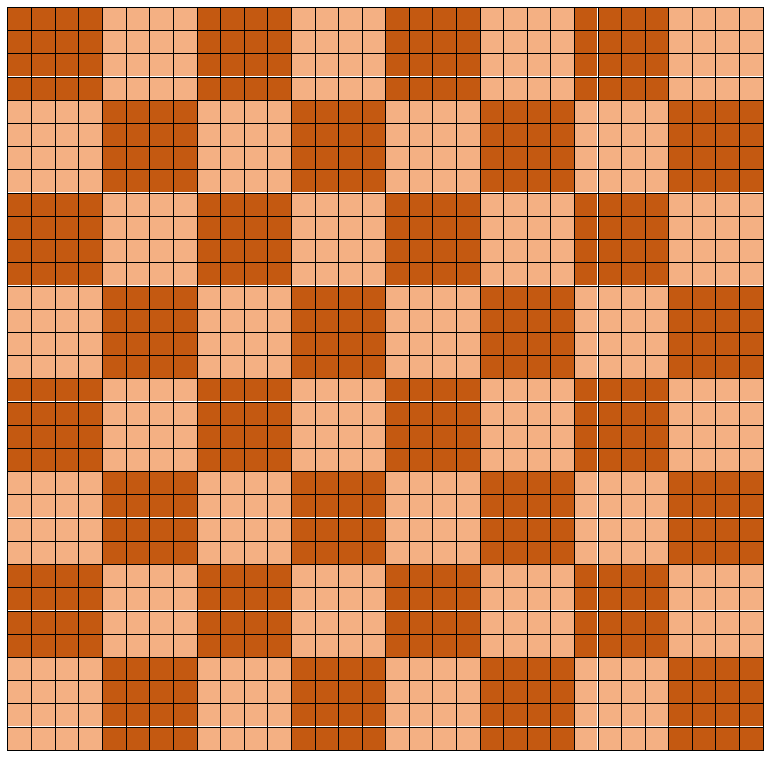

As you can see in the image above, we have 32x32 small squares in the image. Then each 4x4 squares were merged to represent one data point in our data. 

Maybe you are questioning, How??

They are represented by a integer, this integer is the "darkness" of this space in the image. In this data, they have 16 levels of darkness.
So if you try to see the data, it is a matrix 8x8 with numbers from 0 until 16.

Let's call the data

In [ ]:
# LOOK AT THE WAY WE IMPORT THE DATA AND THE MODELS, THERE ARE SEVERAL WAYS TO DO IT. 
# You do not need to know all ways, use the one you likes the most

#Import what is necessary


 
# defining feature matrix(X) and response vector(y)


In [12]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

Split the data in train and test set

In [ ]:
# splitting X and y into training and testing sets


Model

In [ ]:
# create logistic regression object



 
# train the model using the training sets


c:\Users\u0161169\AppData\Local\miniconda3\envs\orient\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Predict

In [ ]:
# making predictions on the testing set


Accuracy

In [ ]:
#Add your code here
accuracy = 
accuracy

0.9652294853963839

If you want more details and also have more mathematical intuituin about Logistic Regression, you can check this website: https://www.geeksforgeeks.org/understanding-logistic-regression/


### And what about the parameters of the model?

Logistic Regression from Scikit-Learn has the following parameters:

**penalty**='l2', 

**dual**=False, 

**tol**=0.0001, 

**C**=1.0, 

**fit_intercept**=True, 

**intercept_scaling**=1, 

**class_weight**=None, 

**random_state**=None, 

**solver**='lbfgs', 

**max_iter**=100, 

**multi_class**='auto', 

**verbose**=0, 

**warm_start**=False, 

**n_jobs**=None, 

**l1_ratio**=None

All the parameters are followed by the defauld attribute from the model.

### Do you know what they means?
Write your answer here: 

After you wrote your answer, please read the documentation:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


And this one:  (JUST THE 1.1.11 AND THE DEPENDENTS)

https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


---> The two links do not explain the penalty. Below you can find more information about the penalty (also called regularization).

- L2 adds “squared magnitude” of coefficient as penalty term to the loss function. The highlighted part represents L2 regularization element.
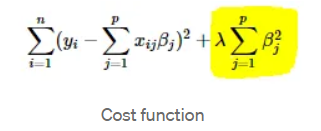

If lambda is zero then you can imagine we get back OLS (Ordinary Least Squares). However, if lambda is very large then it will add too much weight and it will lead to under-fitting. Having said that it’s important how lambda is chosen. This technique works very well to avoid over-fitting issue.

_________________________________________________________________________


- L1 adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
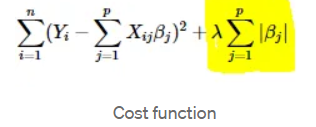

Again, if lambda is zero then we will get back OLS whereas very large value will make coefficients zero hence it will under-fit.

____________________________________________________

**The key difference between these techniques is that L1 shrinks the less important feature’s coefficient to zero thus, removing some feature altogether. So, this works well for feature selection in case we have a huge number of features.**

Answer the following questions:

### Question 4: Check the Digits dataset, for this one which parameters would you use?
(Write which ones you believe to be the best, do not change this answer afterwords)

penalty dual c solver 

### Question 5: Perform a search (Random Search, Grid Search, ...) in some parameters to tune parameters for the Digits dataset.
{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
lr = LogisticRegression(max_iter=2000)

# De ideale, opgesplitste parameter-grid
param_grid = [
    # Grid 1: Voor de supersnelle 'lbfgs' solver (ondersteunt alleen L2-regularisatie)
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    # Grid 2: Voor de 'saga' solver (nodig voor L1 en ElasticNet)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.2, 0.5, 0.8]  # Alleen actief bij elasticnet
    }
]

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy' 
)

grid_search.fit(train_x, train_y)
print(grid_search.cv_results_)
print(grid_search.best_params_)

### Question 6: Check the model performance with the new parameters. Is there a difference?
no is the exact same 0.975

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets,linear_model,metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV as random

digits = datasets.load_digits()
x = digits.data
y = digits.target

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=2000)
model.fit(train_x, train_y)
y_pred = model.predict(test_x)
acc = accuracy_score(test_y, y_pred)
print("accuracy:", acc)

print(x)
print(y)

### Question 7: Why do we need to be careful with the output of the Softmax function when we want to use it as probability?
(Use just the source of this lecture)

Add your answer here